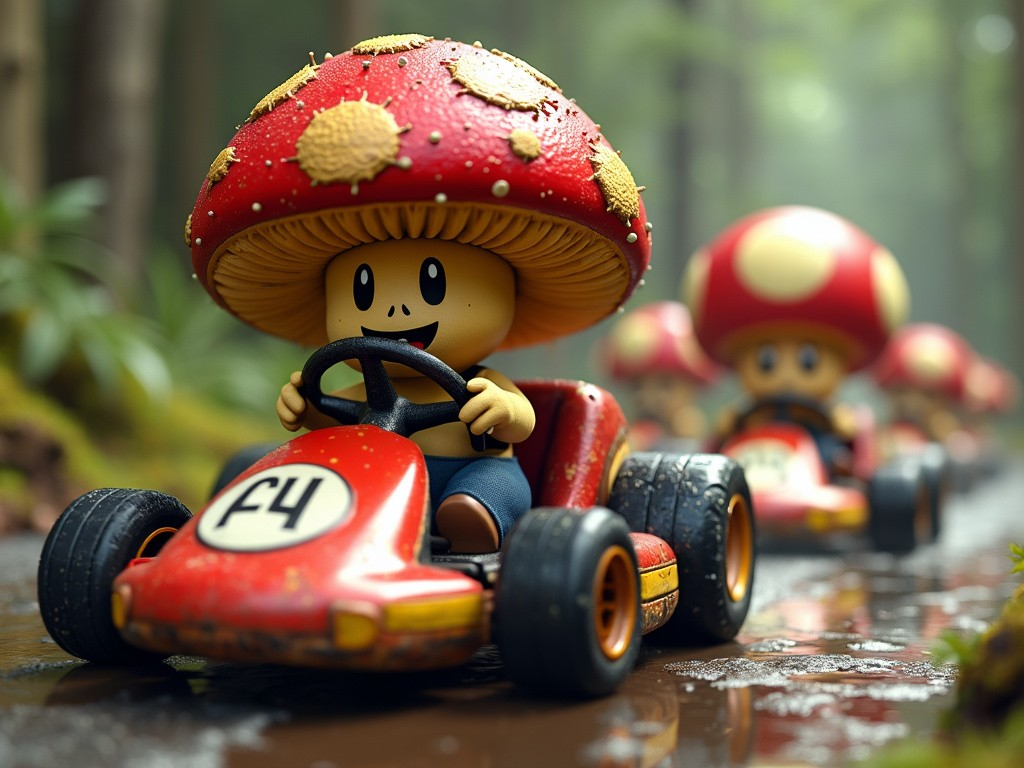

In [ ]:
# %pip install \
#     --extra-index-url=https://pypi.nvidia.com \
#     cudf-cu11==24.8.* cuml-cu11==24.8.*

# %pip install kaggle pandas matplotlib seaborn scikit-learn category_encoders torchmetrics kagtool tqdm xgboost lightgbm catboost optuna fastai loralib

# Preprocess

In [ ]:
# needs a gpu accelerator
%load_ext cudf.pandas

In [ ]:
# Standard library imports
import gc
import os
import time
from pathlib import Path

# Third-party library imports
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific and machine learning libraries
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, matthews_corrcoef, roc_curve, precision_recall_curve, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)

# fastai
from fastai.tabular.all import *

# Gradient boosting libraries
import optuna
import xgboost as xgb
import lightgbm as lgbm
import catboost as cb

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torchmetrics.classification import BinaryAUROC, BinaryMatthewsCorrCoef
from torchmetrics.functional import roc as torch_roc


sns.set_theme(style="whitegrid", palette="muted")
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 140)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

competition = 'playground-series-s4e8'
path = Path('/kaggle/input' if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ else '.')/competition


sample_df = pd.read_csv(path/'sample_submission.csv')
test_df = pd.read_csv(path/'test.csv')

original_df = pd.read_csv('/kaggle/input/tertiary-mushroom-1-million-more-mushrooms/one_million_mushrooms.csv', sep=';')
df = pd.read_csv('/kaggle/input/mushroom-dataset-combined/new_data.csv')
df = pd.concat([df, original_df], ignore_index=True)

# #DEBUG - Just checking to test run the pipeline
# small_df = df.sample(n=1000)

# # Continuous and categorical columns
cont_cols = ["cap-diameter", "stem-height", "stem-width"]
cat_cols = list(set(df.columns) - set(cont_cols) - {"id", "class"})
features = cat_cols + cont_cols

plt.pie(df['class'].value_counts(), labels=['Edible', 'Poisonous'], colors=sns.color_palette("pastel"), autopct='%1.1f%%', startangle=90, 
        wedgeprops=dict(width=0.6, edgecolor='white'))
plt.title('Distribution of Mushroom Predictions', fontweight='bold')
plt.show()
df.head()

# Preprocessing

In [ ]:
def clean_artifacts(df, cat_cols, replace_threshold=100):
    for col in cat_cols:
        if pd.api.types.is_object_dtype(df[col]):
            value_counts = df[col].value_counts()
            infrequent = value_counts < replace_threshold
            df[col] = df[col].where(~df[col].isin(infrequent), 'rare')
            df[col] = df[col].where(~df[col].str.lower().isin(['none', 'nan', 'na']), np.nan)
    return df


def get_to(df, valid_pct):
    df.copy()
    df = clean_artifacts(df, cat_cols)
    random_index = np.random.choice(df.index)

    # there's nan in the test so I want the train to handle this case as well by creatin stem-height-na
    # Set the 'stem-height' value to NaN for the randomly chosen row
    df.loc[random_index, 'stem-height'] = np.nan
    
    return TabularPandas(
        df, splits=RandomSplitter(valid_pct=valid_pct)(df),
        procs = [Categorify, FillMissing, Normalize],
        cat_names=cat_cols.copy(),
        cont_names=cont_cols.copy(),
        y_names="class", y_block = CategoryBlock(),
    )    


to = get_to(df, valid_pct=0)

train_x, train_y = to.train.xs, to.train.ys.values.ravel()
val_x, val_y = to.valid.xs, to.valid.ys.values.ravel()
tr_ds = TensorDataset(torch.tensor(train_x[cat_cols].values, dtype=torch.float32).to(device),
                      torch.tensor(train_x[cont_cols].values, dtype=torch.float32).to(device),
                      torch.tensor(train_y, dtype=torch.float32).to(device).unsqueeze(1))
val_ds = TensorDataset(torch.tensor(val_x[cat_cols].values, dtype=torch.float32).to(device),
                       torch.tensor(val_x[cont_cols].values, dtype=torch.float32).to(device),
                       torch.tensor(val_y, dtype=torch.float32).to(device).unsqueeze(1))
train_x.head()

### Model

In [ ]:
# from fastai
def emb_sz_rule(n_cat: int) -> int:
    "Rule of thumb to pick embedding size corresponding to `n_cat`"
    return min(600, round(1.6 * n_cat**0.56))

def get_emb_sz(cat_df: pd.DataFrame) -> List[Tuple[int, int]]:
    "Get embedding size for each category, adding 1 for the unknown category"
    return [(cat_df[col].max() + 2, emb_sz_rule(cat_df[col].max() + 2)) for col in cat_df.columns]

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, max(channel // reduction, 1), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(channel // reduction, 1), channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c = x.size()
        y = self.avg_pool(x.unsqueeze(-1)).view(b, c)
        y = self.fc(y)
        return x * y

class FlexibleResidualBlock(nn.Module):
    def __init__(self, in_features: int, out_features: int, dropout: float):
        super().__init__()
        self.lin1 = nn.Linear(in_features, out_features)
        self.lin2 = nn.Linear(out_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.se = SEBlock(out_features)
        self.downsample = nn.Linear(in_features, out_features) if in_features != out_features else None

    def forward(self, x):
        identity = x
        out = self.lin1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.lin2(out)
        out = self.bn2(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class EntityEmbeddingsModel(nn.Module):
    def __init__(self, cat_df: pd.DataFrame, cont_df: pd.DataFrame, dropout: float, emb_dropout: float):
        super().__init__()
        
        # Get embedding sizes
        self.emb_sizes = get_emb_sz(cat_df)
        
        # Embedding layers (adding 1 to cat_size for the unknown category)
        self.emb_layers = nn.ModuleList([nn.Embedding(cat_size, emb_size) 
                                         for cat_size, emb_size in self.emb_sizes])
        
        # Store the number of known categories for each variable
        self.known_categories = [cat_df[col].max() + 1 for col in cat_df.columns]
        
        # Calculate the dimension of the embedding output
        self.emb_output_dim = sum([emb_size for _, emb_size in self.emb_sizes])
        
        # Number of continuous features
        self.n_cont = cont_df.shape[1]
        
        # Embedding dropout
        self.emb_dropout = nn.Dropout(emb_dropout)
        
        # Input batch norm
        self.input_bn = nn.BatchNorm1d(self.emb_output_dim + self.n_cont)
        
        # Feedforward layers with residual blocks
        self.fc_layers = nn.Sequential(
            FlexibleResidualBlock(self.emb_output_dim + self.n_cont, 512, dropout),
            FlexibleResidualBlock(512, 256, dropout),
            FlexibleResidualBlock(256, 128, dropout),
            FlexibleResidualBlock(128, 64, dropout),
            nn.Dropout(dropout * 0.5),
            nn.BatchNorm1d(64),
            nn.Linear(64, 1)
        )
        
        # Apply initializations
        self.apply(self.custom_init)
        self.apply(self.embedding_init)
        self.apply(self.residual_init)
        
    def forward(self, x_cat, x_cont):
        # Process categorical data
        x_cat = x_cat.long()
        embeddings = []
        for i, (emb, known_cat) in enumerate(zip(self.emb_layers, self.known_categories)):
            # Map unseen categories to the last index (unknown token)
            x_cat_column = torch.where(x_cat[:, i] < known_cat, x_cat[:, i], torch.tensor(known_cat, device=x_cat.device))
            
            emb_out = emb(x_cat_column)
            # Apply embedding dropout
            if self.training:
                emb_out = self.emb_dropout(emb_out)
            embeddings.append(emb_out)
        
        cat_features = torch.cat(embeddings, 1)
        
        x = torch.cat([cat_features, x_cont], 1)
        x = self.input_bn(x)
        return self.fc_layers(x)

    @staticmethod
    def custom_init(m):
        if isinstance(m, nn.Linear):
            if m.out_features > m.in_features:
                # Expanding layer
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            else:
                # Contracting layer
                nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm1d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

    @staticmethod
    def embedding_init(m):
        if isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0, std=1/m.embedding_dim**0.5)

    @staticmethod
    def residual_init(m):
        if isinstance(m, FlexibleResidualBlock):
            nn.init.zeros_(m.lin2.weight)
            if m.lin2.bias is not None:
                nn.init.zeros_(m.lin2.bias)

### Trainer

In [ ]:
def train_and_evaluate_model(model, tr_ds, val_ds, bs, epochs, lr, max_lr, wd, mcc_threshold, **kwargs):
    start_time = time.time()
    tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr, steps_per_epoch=len(tr_loader), epochs=epochs)
    mcc_metric = BinaryMatthewsCorrCoef(threshold=mcc_threshold).to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0        
        for X_cat_batch, X_cont_batch, y_batch in tqdm(tr_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):
            X_cat_batch, X_cont_batch, y_batch = X_cat_batch.to(device, non_blocking=True), X_cont_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(X_cat_batch, X_cont_batch)
            loss = criterion(logits, y_batch.float())
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        mcc = 0
        all_logits, all_targets = [], []
        if val_ds:
            model.eval()
            valid_loss = 0.0     
            mcc_metric.reset()
            with torch.no_grad():
                for X_cat_batch, X_cont_batch, y_batch in tqdm(val_loader, desc=f"Validating Epoch {epoch+1}/{epochs}"):
                    X_cat_batch, X_cont_batch, y_batch = X_cat_batch.to(device, non_blocking=True), X_cont_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
                    logits = model(X_cat_batch, X_cont_batch)
                    loss = criterion(logits, y_batch.float())
                    valid_loss += loss.item()
                    mcc_metric.update(logits, y_batch)
                    all_logits.append(logits)
                    all_targets.append(y_batch)
            all_logits = torch.cat(all_logits)
            all_targets = torch.cat(all_targets)
            
            mcc = mcc_metric.compute()
            print(
                f"Epoch {epoch+1} done in {time.time() - start_time:.2f} seconds, "
                f"Training Loss: {train_loss/len(tr_loader):.4f}, "
                f"Validation Loss: {valid_loss/len(val_loader):.4f}, "
                f"Validation MCC: {mcc:.4f}"
            )
        else:
            print(
                f"Epoch {epoch+1} done in {time.time() - start_time:.2f} seconds, "
                f"Training Loss: {train_loss/len(tr_loader):.4f}, "                
            )
    return model, all_logits, all_targets, mcc

### Training

In [ ]:
def train_model(train_x, cat_cols, cont_cols, tr_ds, val_ds, device, epochs=16, save_dir='saved_models'):
    params = {
        'bs': 256,
        'epochs': epochs,
        'lr': 3e-4,
        'max_lr': 3e-2,
        'mcc_threshold': 0.5,
        'wd': 3e-4,
        'dropout': 0.2,
        'emb_dropout': 0,
    }
    model = EntityEmbeddingsModel(cat_df=train_x[cat_cols], cont_df=train_x[cont_cols],
                                  dropout=params['dropout'], emb_dropout=params['emb_dropout']).to(device)
    trained_model, all_logits, all_targets, mcc = train_and_evaluate_model(model, tr_ds, val_ds, **params)
    print(f"Final MCC: {mcc:.4f}")
    return trained_model, params, mcc, all_logits, all_targets


if not 'val_ds' in locals():
    val_ds = None
best_model, best_params, best_mcc, all_logits, all_targets = train_model(
    train_x, cat_cols, cont_cols, tr_ds, val_ds, device, epochs=10
)

# Test DF

In [ ]:
def get_test_dl(test_df, bs):
    test_df = test_df.copy()
    test_df = clean_artifacts(test_df, cat_cols)
    return to.train.dataloaders(bs=bs).test_dl(test_df)

def predict(model, X_cat, X_cont):
    model.eval()  # Ensure the model is in evaluation mode
    with torch.no_grad():  # No need to track gradients
        X_cat = X_cat.to(device, non_blocking=True)
        X_cont = X_cont.to(device, non_blocking=True)
        logits = model(X_cat, X_cont)
        probabilities = torch.sigmoid(logits)  # Convert logits to probabilities
        predictions = (probabilities > 0.5).long()  # Threshold at 0.5 for binary classification
    return predictions

test_df = pd.read_csv(path/'test.csv')
test_dls = get_test_dl(test_df, bs=16384)
logits = []
for X_cat_batch, X_cont_batch in tqdm(test_dls, desc="Processing batches"):        
    output = predict(best_model, X_cat_batch, X_cont_batch)
    logits.append(output)
test_preds = torch.cat(logits, dim=0)
test_preds = test_preds.cpu().numpy().flatten()

print(f"Test predictions shape: {test_preds.shape}")
print(f"Number of positive predictions: {test_preds.sum().item()}")
print(f"Percentage of positive predictions: {(test_preds.sum() / len(test_preds) * 100):.2f}%")
print(test_preds)

# Submission

In [ ]:
submission = pd.DataFrame({
    'id': test_df['id'].values,
    'class': pd.Series(test_preds, index=test_df.index).map({0: 'e', 1: 'p'})
}, index=test_df.index)
file_name = f'mushroom_subm_{type(best_model).__name__}'
submission.to_parquet(f'{file_name}.parquet', index=False)
submission.to_csv(f'{file_name}.csv', index=False)
submission.to_csv('submission.csv', index=False)

plt.pie(submission['class'].value_counts(), labels=['Edible', 'Poisonous'], colors=sns.color_palette("pastel"), autopct='%1.1f%%', startangle=90, 
        wedgeprops=dict(width=0.6, edgecolor='white'))
plt.title('Distribution of Mushroom Predictions', fontweight='bold')
plt.show()

assert submission.isna().sum().sum() == 0, "NaN values found in submission DataFrame"

# Credit
Thanks to ahsuna123 and carlmcbrideelis for the awesome datasets!!
- https://www.kaggle.com/datasets/ahsuna123/mushroom-dataset-combined
- https://www.kaggle.com/datasets/carlmcbrideellis/tertiary-mushroom-1-million-more-mushrooms
